In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, Dropdown, IntSlider
import xlrd

## **1. Data Preparation:**

In [4]:
df=pd.read_excel('US Superstore data.xls')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Notre dataset comporte 21 variables et 9994 données. De plus, les différentes données correspontes à leur type fournie

In [10]:
df.duplicated().sum()

np.int64(0)

On observe qu'il n'y pas de doublon dans les données

### **Feature engeenering**

In [11]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

In [12]:
# Display sample of new features
print("New features created:")
df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head()

New features created:


,Sales,Profit,Profit Margin,Order Year,Order Month
0,261.9600,41.9136,16.00,2016,11
1,731.9400,219.5820,30.00,2016,11
2,14.6200,6.8714,47.00,2016,6
3,957.5775,-383.0310,-40.00,2015,10
4,22.3680,2.5164,11.25,2015,10


Ces nouvelles vont améliorer notre méthode d'analyse car on pourra passer d'une analyse global à une analyse détaillée

In [18]:
trend = df.groupby('Order Year')['Sales'].sum().reset_index()

In [29]:
trend

,Order Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


## **2. Data Visualization with Matplotlib:**

### **Vente au fil des années**

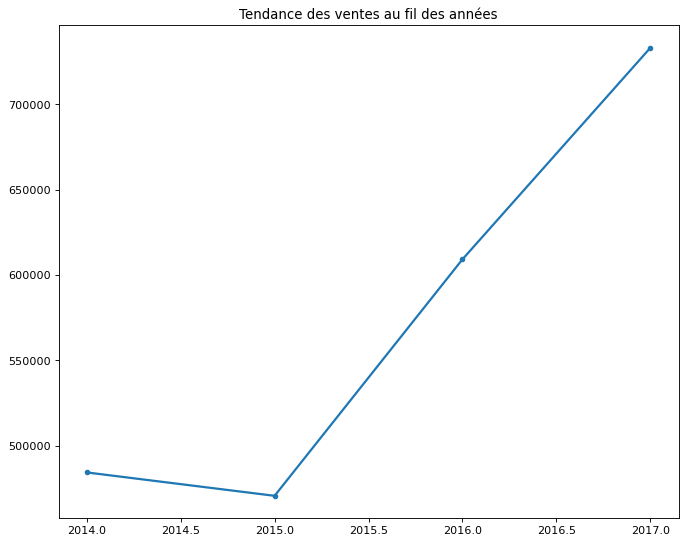

In [30]:
plt.figure(figsize=(10,8),dpi=80)
plt.plot(trend['Order Year'], trend['Sales'],marker='o', linewidth=2, markersize=4)
plt.title('Tendance des ventes au fil des années')
plt.show()

À partir de 2014, les ventes avaient commencé à chuter, c'est à partir de 2025 qu'elles ont réellement augmenté, puis ont continué à croître au fil des années.

### **Visualization sales distribution by country**

In [41]:
# Prepare geographic sales data
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

# Interactive geographic analysis
def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    # Get top N states
    top_states = state_sales.tail(top_n)

    # Create horizontal bar chart
    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

    # Add value labels on bars
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values) * 0.01, i, f'${value:,.0f}', 
                va='center', fontsize=10)

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive slider
top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

Dans cette partie, nous pouvons vérifier la performance de chaque Etat. On constate que la californie et new york sont les pays qui vende le plus.

## **3. Data Visualization with Seaborn:**

### **Top 10 products by sales**

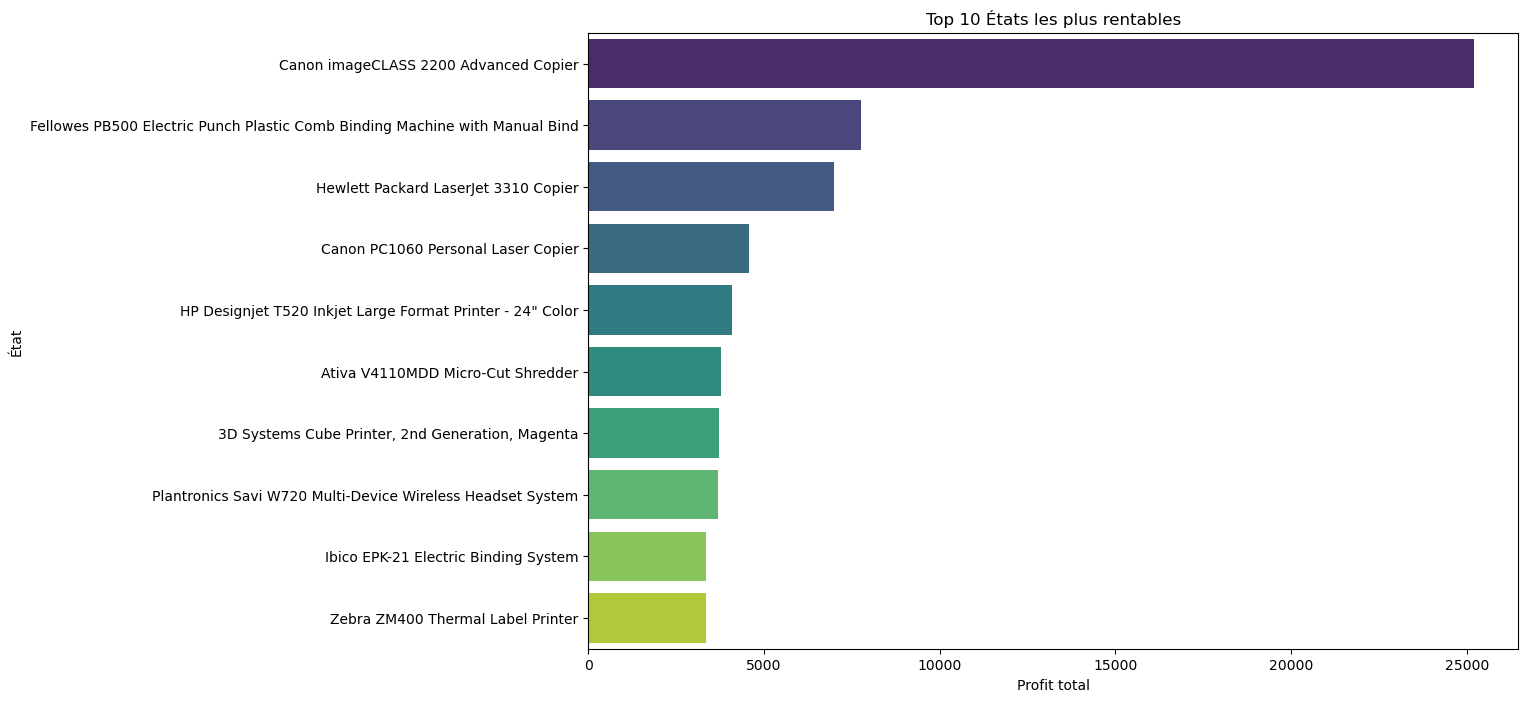

In [45]:
top_10_product = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,8),dpi=100)
sns.barplot(
    x=top_10_product.head(10).values,
    y=top_10_product.head(10).index,
    hue= top_10_product.head(10).index,
    palette='viridis'
)

plt.title('Top 10 États les plus rentables')
plt.xlabel('Profit total')
plt.ylabel('État')
plt.show()

Ici, le produit le plus vendu est le Canon imageCLASS 2200 Advanced Copier avec un total de vente de  25199.92$, suivie du Fellowes PB500 Electric Punch (7753.03$) et du Hewlett Packard LaserJet 3310 Copier (6983.88$)

### **Relationship between profit and discount**

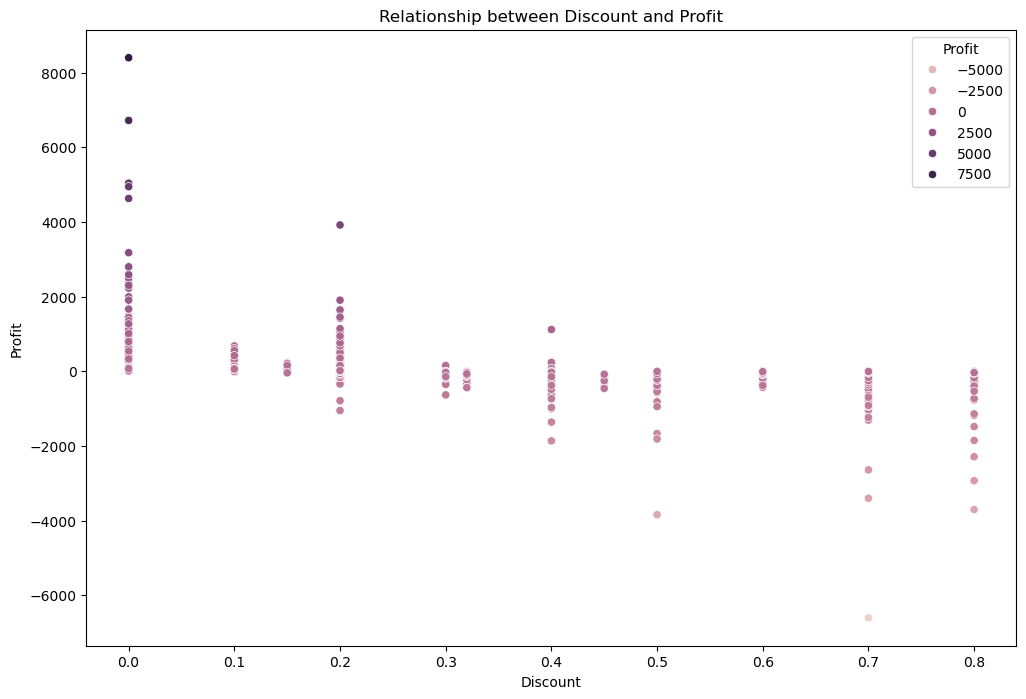

In [52]:
plt.figure(figsize=(12,8),dpi=100)
sns.scatterplot(data=df,x='Discount',y='Profit',hue='Profit')
plt.title('Relationship between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

Les remises sur le mobilier supérieures à 20 % entraînent des pertes de profit moyennes de 15 %. Il est donc important de limiter les remises standard sur le mobilier à un maximum de 20 % et de mettre en place une procédure d'approbation pour les exceptions.

## **4. Comparative Analysis:**

### **Matplotlib and Seaborn visualizations**

Points forts de Matplotlib (d'après notre analyse) :
* Contrôle précis des widgets interactifs
* Annotations personnalisées et positionnement du texte
* Mise en page précise des sous-graphiques et dimensionnement des figures
* Intégration avec ipywidgets pour des mises à jour dynamiques  

Points forts de Seaborn (d'après notre analyse) :
* Visualisations statistiques intégrées (regplot)
* Palettes de couleurs et légendes automatiques
* Style par défaut clair et prêt pour la publication
* Visualisation aisée des données catégorielles

### **The ease of use and effectiveness of both tools**

Matplotlib est la bibliothèque de base pour les graphiques en Python, il permet un contrôle total sur ceux-ci et de les personnaliser comme bon le semble, idéal si on veut créer les nôtres. Cependant, cela prend du temps à être mis en place. Pour aller plus vite dans un projet, il est nécessaire d'utiliser une bibliothèque qui compense les limitations de Matplotlib, c'est pourquoi Seaborn a été développé. Seaborn est une bibliothèque graphique dérivée de Matplotlib, conçue pour faciliter la création de graphiques. Il possède déjà plusieurs éléments automatiques qui sont ajoutés lors de la création d'un graphe, comme les couleurs, les légendes, etc. Il est facile d'utilisation et prend moins de temps à être mise en place.